In [1]:
from google.colab import files
uploaded = files.upload()

Saving titanic.csv to titanic.csv


In [3]:
import pandas as pd

data = pd.read_csv("titanic.csv")
print(data.head())
print(data.info())

   PassengerId  Survived  Pclass  \
0            1         0       3   
1            2         1       1   
2            3         1       3   
3            4         1       1   
4            5         0       3   

                                                Name     Sex   Age  SibSp  \
0                            Braund, Mr. Owen Harris    male  22.0      1   
1  Cumings, Mrs. John Bradley (Florence Briggs Th...  female  38.0      1   
2                             Heikkinen, Miss. Laina  female  26.0      0   
3       Futrelle, Mrs. Jacques Heath (Lily May Peel)  female  35.0      1   
4                           Allen, Mr. William Henry    male  35.0      0   

   Parch            Ticket     Fare Cabin Embarked  
0      0         A/5 21171   7.2500   NaN        S  
1      0          PC 17599  71.2833   C85        C  
2      0  STON/O2. 3101282   7.9250   NaN        S  
3      0            113803  53.1000  C123        S  
4      0            373450   8.0500   NaN        S  
<c

/tmp/ipykernel_9395/221922667.py:27: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  data["Age"].fillna(data["Age"].mean(), inplace=True)
/tmp/ipykernel_9395/221922667.py:28: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', 

Decision Tree (Overfit): 0.7932960893854749 0.7516778523489933 0.7913127413127413
Decision Tree (Pruned): 0.7988826815642458 0.7391304347826086 0.8463320463320464
Random Forest: 0.8100558659217877 0.7605633802816901 0.8874517374517376
OOB Score (RF): 0.797752808988764

✅ model.pkl saved successfully!


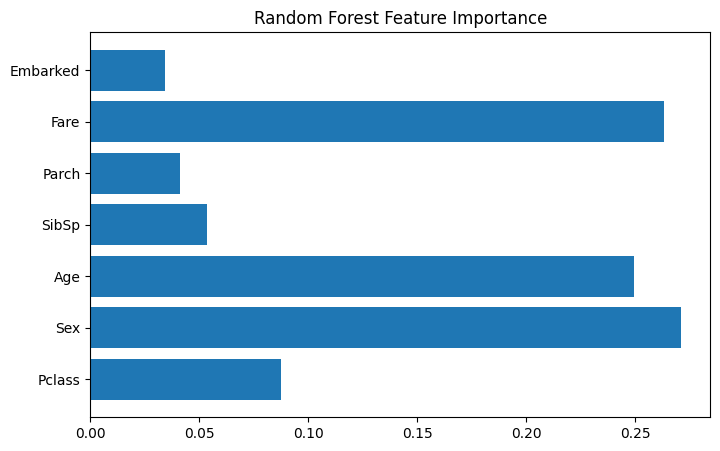

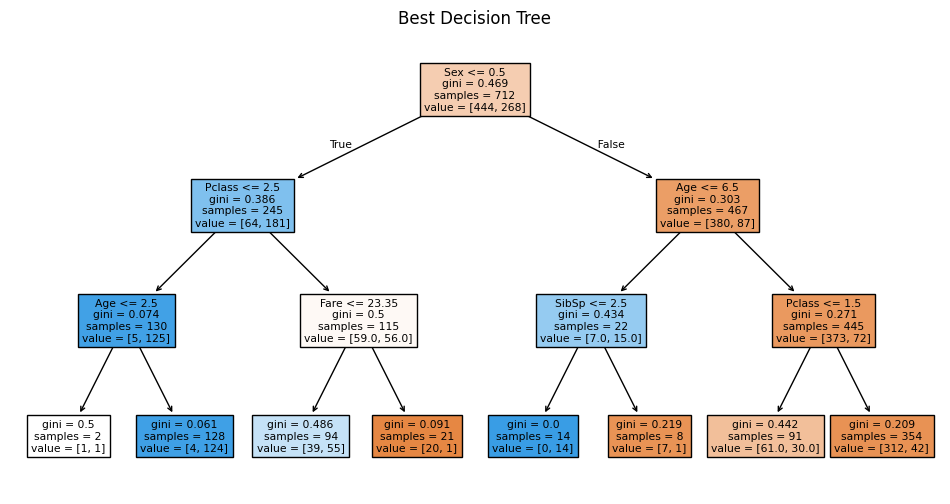


Final Comparison Table:
           Model  Accuracy  F1 Score       AUC
0     DT Overfit  0.793296  0.751678  0.791313
1      DT Pruned  0.798883  0.739130  0.846332
2  Random Forest  0.810056  0.760563  0.887452


In [5]:
# ================================
# IMPORTS
# ================================
import numpy as np
import pandas as pd
import joblib
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, f1_score, roc_auc_score

# ================================
# LOAD DATA
# ================================
data = pd.read_csv("titanic.csv")

# ================================
# SELECT IMPORTANT FEATURES ONLY
# ================================
data = data[["Survived","Pclass","Sex","Age","SibSp","Parch","Fare","Embarked"]]

# ================================
# HANDLE MISSING VALUES
# ================================
data["Age"].fillna(data["Age"].mean(), inplace=True)
data["Embarked"].fillna("S", inplace=True)

# ================================
# ENCODING (MATCH STREAMLIT)
# ================================
# male = 1, female = 0
data["Sex"] = data["Sex"].map({"male":1, "female":0})

# C=0, Q=1, S=2
data["Embarked"] = data["Embarked"].map({"C":0, "Q":1, "S":2})

# ================================
# SPLIT FEATURES & TARGET
# ================================
X = data.drop("Survived", axis=1)
y = data["Survived"]

# ================================
# TRAIN TEST SPLIT
# ================================
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# ================================
# 1️⃣ DECISION TREE (OVERFIT)
# ================================
dt = DecisionTreeClassifier(random_state=42)
dt.fit(X_train, y_train)

# ================================
# 2️⃣ GRID SEARCH (PRE-PRUNING)
# ================================
param_grid = {
    "max_depth": [3,5,10,None],
    "min_samples_split": [2,5,10],
    "min_samples_leaf": [1,2,4]
}

grid = GridSearchCV(DecisionTreeClassifier(random_state=42),
                    param_grid, cv=5)
grid.fit(X_train, y_train)

best_dt = grid.best_estimator_

# ================================
# 3️⃣ RANDOM FOREST
# ================================
rf = RandomForestClassifier(
    n_estimators=100,
    oob_score=True,
    random_state=42
)
rf.fit(X_train, y_train)

# ================================
# EVALUATION FUNCTION
# ================================
def evaluate(model):
    y_pred = model.predict(X_test)
    acc = accuracy_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)
    auc = roc_auc_score(y_test, model.predict_proba(X_test)[:,1])
    return acc, f1, auc

acc_dt, f1_dt, auc_dt = evaluate(dt)
acc_best, f1_best, auc_best = evaluate(best_dt)
acc_rf, f1_rf, auc_rf = evaluate(rf)

# ================================
# PRINT RESULTS
# ================================
print("Decision Tree (Overfit):", acc_dt, f1_dt, auc_dt)
print("Decision Tree (Pruned):", acc_best, f1_best, auc_best)
print("Random Forest:", acc_rf, f1_rf, auc_rf)
print("OOB Score (RF):", rf.oob_score_)

# ================================
# SAVE BEST MODEL (FOR STREAMLIT)
# ================================
joblib.dump(rf, "model.pkl")   # RF best for dashboard

print("\n✅ model.pkl saved successfully!")

# ================================
# FEATURE IMPORTANCE PLOT
# ================================
plt.figure(figsize=(8,5))
plt.barh(X.columns, rf.feature_importances_)
plt.title("Random Forest Feature Importance")
plt.show()

# ================================
# TREE VISUALIZATION
# ================================
plt.figure(figsize=(12,6))
plot_tree(best_dt, filled=True, feature_names=X.columns)
plt.title("Best Decision Tree")
plt.show()

# ================================
# FINAL TABLE
# ================================
results = pd.DataFrame({
    "Model": ["DT Overfit", "DT Pruned", "Random Forest"],
    "Accuracy": [acc_dt, acc_best, acc_rf],
    "F1 Score": [f1_dt, f1_best, f1_rf],
    "AUC": [auc_dt, auc_best, auc_rf]
})

print("\nFinal Comparison Table:")
print(results)

In [6]:
import pickle

# Save Decision Tree (pruned best model)
with open("decision_tree.pkl", "wb") as f:
    pickle.dump(best_dt, f)

# Save Random Forest
with open("random_forest.pkl", "wb") as f:
    pickle.dump(rf, f)

print("✅ Models saved successfully!")

✅ Models saved successfully!


In [7]:
from google.colab import files

files.download("decision_tree.pkl")
files.download("random_forest.pkl")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>